In [1]:
import os 
import sys
import re 
import numpy as np 
import pandas as pd 
import plotly.graph_objects as go 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import pdb_functions as pu 
# import voxel_functions as vf
import color_function as cf 
import plot_functions as pf 
# import BindingCavity_functions as bc 
# import SequenceAlignment_functions as sa 

In [3]:
"""
Load pS6-IP data
"""

ps6_df = pd.read_csv('../../files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df.odor_category = ps6_df.odor_category.astype(pd.CategoricalDtype(categories=['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 'Esters',
                                                                                   'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous', 'Others'], ordered=True))

# Subset for concentration in percentages 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')]
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()
ps6_df = ps6_df[ps6_df.odor_category != 'Others']

ODOR_CATEGORIES = ps6_df.odor_category.sort_values().unique()
ODORS = [_odor for _cat in ODOR_CATEGORIES for _odor in ps6_df[ps6_df.odor_category == _cat].dropna().sort_values(['cid_mw', 'odor']).odor.unique()]
ODOR_TO_CAT = dict(zip(ps6_df.odor, ps6_df.odor_category))
CATEGORY_COLORS = cf.distinct_colors(ODOR_CATEGORIES, category = 'tab10')
ODOR_COLORS = {}
for _category in ODOR_CATEGORIES:     
    ODOR_COLORS.update(cf.generate_faded_shades(CATEGORY_COLORS[_category],
                                     list(ps6_df[ps6_df.odor_category == _category].sort_values(['cid_mw', 'odor']).odor.unique()), 
                                     (0.4,0.8)))

# Define custom cmap for activation zscore 
import plotly.graph_objects as go
import numpy as np
from matplotlib import cm, colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

base = plt.cm.RdBu_r(np.linspace(0, 1, 256))
colors = []

blue_part = [mcolors.to_hex(_rgb) for _rgb in base[:100]]       # negative
zero_part = ["#FFFFFF"] * 50        # neutral (between -2 and 2)
red_part = [mcolors.to_hex(_rgb) for _rgb in base[-100:]]       # positive

colors = blue_part + zero_part + red_part

RdBu_list = [(i / (len(colors) - 1), colors[i]) for i in range(len(colors))]

from matplotlib.colors import ListedColormap
RdBu_cmap = ListedColormap(colors)


### ESM Plots

#### ESM PCA 

In [29]:
pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_esm_coords.csv', index_col = 0)
variance_ratio = np.load('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_ESM_variance_ratio.npy')
pca_df = pca_df[~pca_df.index.str.isupper()] # Exclude HS data 

In [30]:
"""
Quick empty plot 
"""
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = pca_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Class'].unique()), custom_color=['#9A9C99', '#CDCFCC'])

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.PCA_1,
    y=plot_df.PCA_2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color='#D3D3D3',
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
# fig.write_image('../../output/pub_Figures/ESM/PCA_esm_class.png', 
#                 width=500, height=500, scale=3)

In [23]:
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = pca_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Class'].unique()), custom_color=['#9A9C99', '#CDCFCC'])

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.PCA_1,
    y=plot_df.PCA_2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Class']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/ESM/PCA_esm_class.png', 
                width=500, height=500, scale=3)

In [24]:
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = pca_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Family'].unique()), category='tab20')

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.PCA_1,
    y=plot_df.PCA_2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Family']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/ESM/PCA_esm_family.png', 
                width=500, height=500, scale=3)

In [25]:
pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/AF3/ESM/pca_Cbc_ESM.csv', index_col = 0)
variance_ratio = np.load('/mnt/data2/Justice/OR_learning/output/AF3/ESM/pca_Cbc_ESM_variance_ratio.npy')
pca_df = pca_df[~pca_df.index.str.isupper()] # Exclude HS data 

In [26]:
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = pca_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Class'].unique()), custom_color=['#9A9C99', '#CDCFCC'])

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.PCA_1,
    y=plot_df.PCA_2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Class']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/ESM/PCA_Cbc_esm_class.png', 
                width=500, height=500, scale=3)

In [27]:
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = pca_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Family'].unique()), category='tab20')

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.PCA_1,
    y=plot_df.PCA_2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Family']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.8))
fig.update_layout(xaxis_title = f'PC1 ({variance_ratio[0]*100:.2f}%)',
                  yaxis_title = f'PC2 ({variance_ratio[1]*100:.2f}%)',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/ESM/PCA_Cbc_esm_family.png', 
                width=500, height=500, scale=3)

#### ESM Full vs Cbc

In [305]:
from scipy.spatial.distance import pdist
from itertools import combinations

pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/pca_Cbc_esm_coords.csv', index_col = 0)
pca_df.index = pca_df.index.str.capitalize()

# Get PCA from Full sequence embedding 
pca_full = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_esm_coords.csv', index_col = 0)

pca_df = pca_df[pca_df.index.isin(list(set(pca_df.index).intersection(set(pca_full.index))))]

# Compute pairwise distances (returns condensed form)
pca_dist = pdist(pca_df[['PCA_1', 'PCA_2']], metric='euclidean')
pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)

pca_full = pca_full[pca_full.index.isin(pca_df.index)] # Ensure the same ORs. 
pca_dist = pdist(pca_full[['PCA_1', 'PCA_2']], metric='euclidean')
full_pca_zscore = (pca_dist - np.mean(pca_dist)) / np.std(pca_dist)

# Get pairwise indices for upper triangle
or_names = pca_df.index.to_list()
pairs = list(combinations(or_names, 2))  

# Create labeled DataFrame
pca_distance = pd.DataFrame(pairs, columns=['OR1', 'OR2'])
pca_distance['Cbc_ESM_Distance'] = pca_zscore
pca_distance['Full_ESM_Distance'] = full_pca_zscore


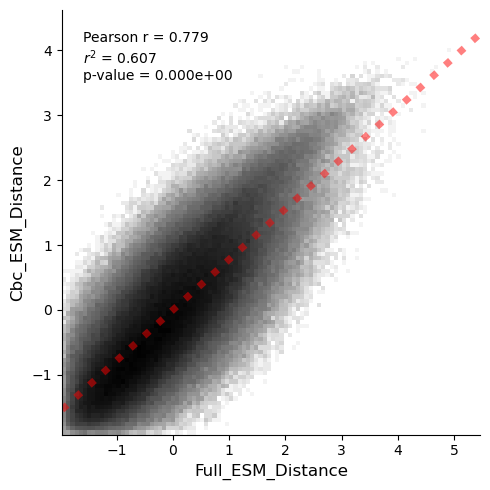

In [307]:
fig, ax = pf.plt_correlation(pca_distance['Full_ESM_Distance'], 
                             pca_distance['Cbc_ESM_Distance'], 
                             xlabel = 'Full_ESM_Distance', 
                             ylabel = 'Cbc_ESM_Distance',
                             plot_style = 'hist2d', cmap='Greys',
                             linecolor='Red', linewidth=5,
                             pearson_fontsize=10,
                             figsize=[5,5])

fig.savefig('../../output/pub_Figures/ESM/corr_ESM_PCAdist_Cbc_Full.svg', dpi=500)
fig.show()

#### Grantham MDS 

In [393]:
mds_df = pd.read_csv('../../output/Canonical_bc/SeqAlignment/SeqAlignment_Full_grantham_mds_coords.csv', index_col = 0)
mds_df.indexx = mds_df.index.str.capitalize()
mds_df['Family'] = [re.match(r'Or(\d+)', _OR, flags=re.IGNORECASE).group(1) if re.match(r'Or(\d+)', _OR, flags=re.IGNORECASE) else 'None' for _OR in mds_df.index]
mds_df['Class']  = [1 if _fam in map(str, range(51, 57)) else 2 for _fam in mds_df.Family]
mds_df.index.name = 'idx'
mds_df = mds_df.sort_values(['Class', 'Family', 'idx'], ascending=[False, True, True]) # Sort order before saving

/tmp/ipykernel_694658/762856711.py:2: UserWarning:

Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access



In [394]:
import plotly.graph_objects as go 

plot_df = mds_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Class'].unique()), custom_color=['#9A9C99', '#CDCFCC'])

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.MDS1,
    y=plot_df.MDS2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Class']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.7))
fig.update_layout(xaxis_title = f'MDS1',
                  yaxis_title = f'MDS2',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/Grantham/MDS_Full_esm_class.png', 
                width=500, height=500, scale=3)

In [395]:
import plotly.graph_objects as go 


# plot_df = pca_df[pca_df.Class > 1]
plot_df = mds_df.copy()
# Define colors for each class
colormap = cf.distinct_colors(np.sort(plot_df['Family'].unique()), category='tab20')

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df.MDS1,
    y=plot_df.MDS2,
    text=plot_df.index,
    mode='markers',
    marker=dict(
        color=[colormap.get(_class) for _class in plot_df['Family']],
    )
))

fig.update_traces(marker=dict(size=7, opacity = 0.7))
fig.update_layout(xaxis_title = f'MDS1',
                  yaxis_title = f'MDS2',
                  margin=dict(r=10, l=10, b=10, t=10),
                  plot_bgcolor='white', 
                  paper_bgcolor='white',
                  width=500, height=500
)
fig.update_xaxes(showticklabels=False, ticks="")
fig.update_yaxes(showticklabels=False, ticks="")
fig.show()
fig.write_image('../../output/pub_Figures/Grantham/MDS_Full_esm_family.png', 
                width=500, height=500, scale=3)

#### Grantham vs ESM

In [ ]:
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

esm_pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/pca_esm_coords.csv', index_col=0)  # Full ESM pca
esm_cbc_pca_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/ESM/PCA/Cbc_esm/pca_Cbc_esm_coords.csv', index_col = 0) # CBC ESM pca 
esm_pca_df.index = esm_pca_df.index.str.capitalize()
esm_cbc_pca_df.index = esm_cbc_pca_df.index.str.capitalize()

# === MDS Grantham distance === 
mds_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Canonical_bc/SeqAlignment/SeqAlignment_Full_grantham_dist_mtx.csv', index_col = 0)
cbc_mds_df = pd.read_csv('/mnt/data2/Justice/OR_learning/output/Canonical_bc/SeqAlignment/SeqAlignment_Cbc_grantham_dist_mtx.csv', index_col = 0)

#Reindex based on pca_df 
or_set = set(esm_cbc_pca_df.index).intersection(set(mds_df.index))
esm_pca_df = esm_pca_df[esm_pca_df.index.isin(or_set)]
esm_cbc_pca_df = esm_cbc_pca_df[esm_cbc_pca_df.index.isin(or_set)]


mds_df = mds_df.reindex(esm_pca_df.index).loc[:,esm_pca_df.index] # Filter rows and columns by overlapping OR with pca 
i, j = np.triu_indices_from(mds_df, k=1)

mds_dist = mds_df.values[i, j]
mds_zscore = (mds_dist - np.mean(mds_dist)) / np.std(mds_dist)
mds_distance = pd.DataFrame({"OR1": mds_df.index[i],
                             "OR2": mds_df.columns[j],
                             "Grantham_Distance": mds_zscore})

cbc_mds_df = cbc_mds_df.reindex(esm_pca_df.index).loc[:,esm_pca_df.index] # Filter rows and columns by overlapping OR with pca 
mds_dist = cbc_mds_df.values[i, j]
mds_zscore = (mds_dist - np.mean(mds_dist)) / np.std(mds_dist)
mds_cbc_distance = pd.DataFrame({"OR1": cbc_mds_df.index[i],
                                 "OR2": cbc_mds_df.columns[j],
                                 "Grantham_CBC_Distance": mds_zscore})



esm_distance = pf.compute_pairwise_pca_distance(esm_pca_df[['PCA_1', 'PCA_2']], 
                                                zscore=True, 
                                                colnames = ['OR1', 'OR2', 'ESM_Distance'])

esm_cbc_distance = pf.compute_pairwise_pca_distance(esm_cbc_pca_df[['PCA_1', 'PCA_2']], 
                                                zscore=True, 
                                                colnames = ['OR1', 'OR2', 'ESM_CBC_Distance'])

# === Join dataframe === 
esm_distance = pd.merge(esm_distance, esm_cbc_distance, on = ['OR1', 'OR2'], how='left')
mds_distance = pd.merge(mds_distance, mds_cbc_distance, on = ['OR1', 'OR2'], how='left')
distance_df = pd.merge(esm_distance, mds_distance, on = ['OR1', 'OR2'], how='left')

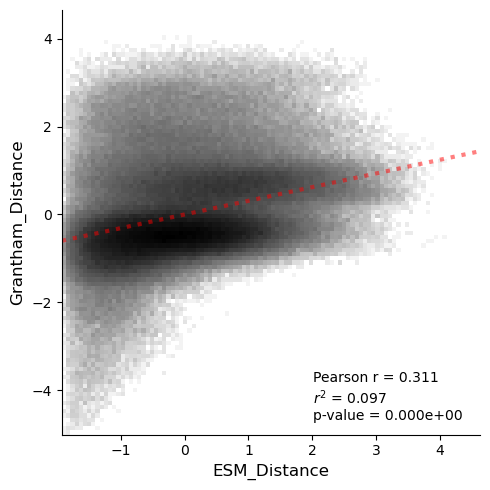

In [27]:
fig, _ = pf.plt_correlation(distance_df['ESM_CBC_Distance'], 
                   distance_df['Grantham_Distance'], 
                   xlabel = 'ESM_Distance', 
                   ylabel = 'Grantham_Distance',
                   plot_style='hist2d',
                   pearson_text_pos='bottom,right',
                   text_xy = [0.6,0.15],
                   pearson_fontsize=10,
                   opacity = 0.01)

# fig.savefig('/mnt/data2/Justice/OR_learning/output/pub_Figures/ESM/corr_ESM_PCAdist_grantham.svg')
# fig.savefig('/mnt/data2/Justice/OR_learning/output/pub_Figures/ESM/corr_CbcESM_PCAdist_grantham.svg')


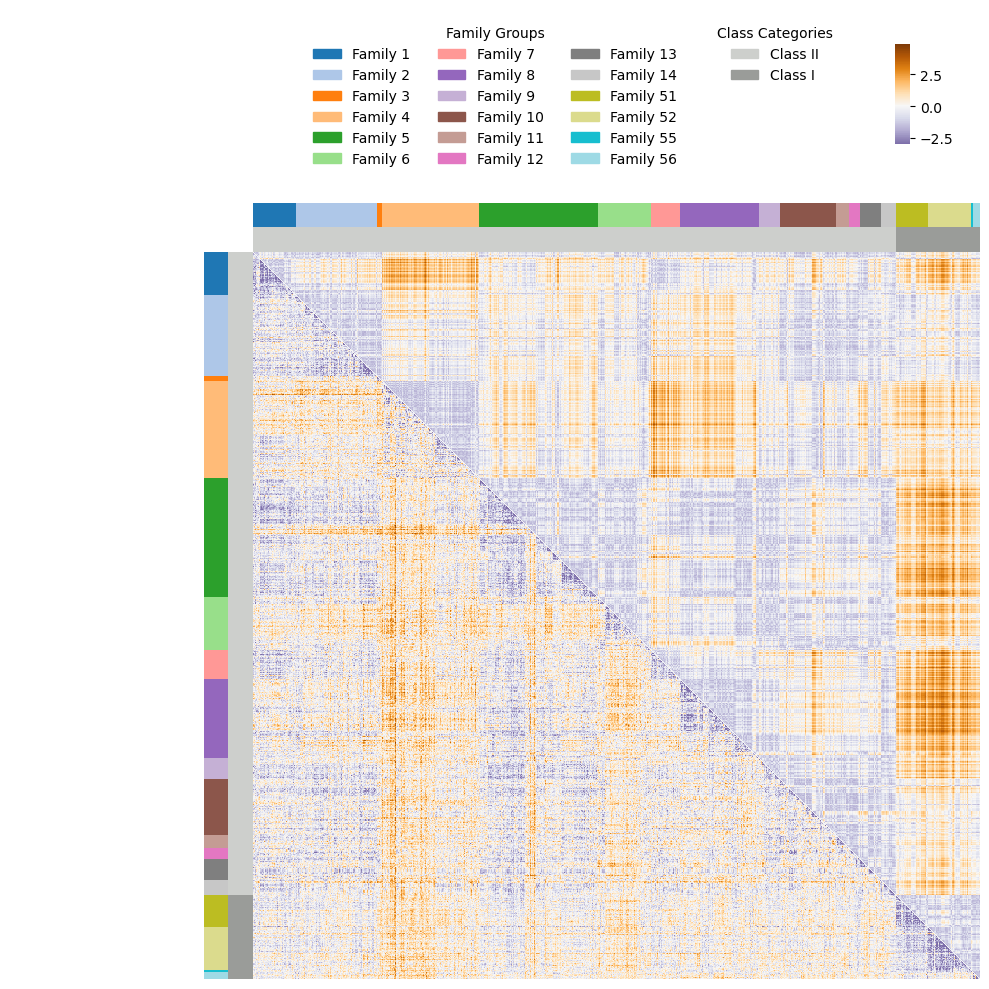

In [50]:
import seaborn as sns 
import matplotlib.patches as mpatches

plot_upper = 'ESM_CBC_Distance'
plot_lower = 'Grantham_CBC_Distance'

# Join ESM and MDS zscore togetehr
mask_upper = np.triu(squareform(distance_df[plot_upper]), k=1).astype(bool)
mask_lower = np.tril(squareform(distance_df[plot_lower]), k=-1).astype(bool)

plot_df = pd.DataFrame(np.zeros_like(squareform(distance_df[plot_upper])), 
                       index=esm_pca_df.index, 
                       columns=esm_pca_df.index)
plot_df.values[mask_upper] = pd.DataFrame(squareform(distance_df[plot_upper])).values[mask_upper]
plot_df.values[mask_lower] = pd.DataFrame(squareform(distance_df[plot_lower])).values[mask_lower]

plot_df_index = pd.Series((re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None) 
                          for _OR in plot_df.index).astype(int)



# Assign cluster colors based on family 
colors = cf.distinct_colors(plot_df_index.unique(), 
                                category='tab20')
colors = {_key: _color.upper() for _key, _color in colors.items()}

index_colors = plot_df_index.map(colors)
index_colors = [ _color.upper() for _color in index_colors]
# Assign secondary colors based on class
class_colors = sns.cubehelix_palette(2,light=.7, dark=.5, start=1, rot=3)
index_colors_class = ['#CDCFCC' if _index in range(1,15) else  '#9A9C99' for _index in plot_df_index]


# Create family/class name mappings for the legend
family_names = {family_id: f"Family {family_id}" for family_id in plot_df_index.unique()}
class_names = {
    '#CDCFCC': 'Class II',
     '#9A9C99': 'Class I'
}

# Plot the heatmap
g = sns.clustermap(plot_df, 
               cmap = 'PuOr_r',
               vmin=-3, 
            #    vmax=3,
               center = 0, 
               cbar_pos = (0.9, 0.85, 0.015, 0.1), 
               row_colors = [index_colors, index_colors_class], 
               col_colors = [index_colors, index_colors_class],
               colors_ratio=(0.025, 0.025), 
               row_cluster = False, col_cluster = False,
               figsize=(10, 10), 
               xticklabels=False, yticklabels=False
               )


# Add legends for the family colors
family_handles = [mpatches.Patch(color=color, label=family_names[family_id]) 
                 for family_id, color in colors.items()]
class_handles = [mpatches.Patch(color=color, label=name) 
                 for color, name in class_names.items()]

# Position the legends
# Family legend - on top left corner
family_legend = g.fig.legend(handles=family_handles, 
                            title="Family Groups",
                            loc="upper center", 
                            bbox_to_anchor=(0.5, 0.98), 
                            frameon=False,
                            ncol=3)  # Adjust number of columns as needed

# Class legend - on top right corner
class_legend = g.fig.legend(handles=class_handles, 
                           title="Class Categories",
                           loc="upper right", 
                           frameon=False,
                           bbox_to_anchor=(0.85, 0.98))

g.savefig('../../output/pub_Figures/ESM/Heatmap_ESMvsGrantham_CBC.png', dpi=500)


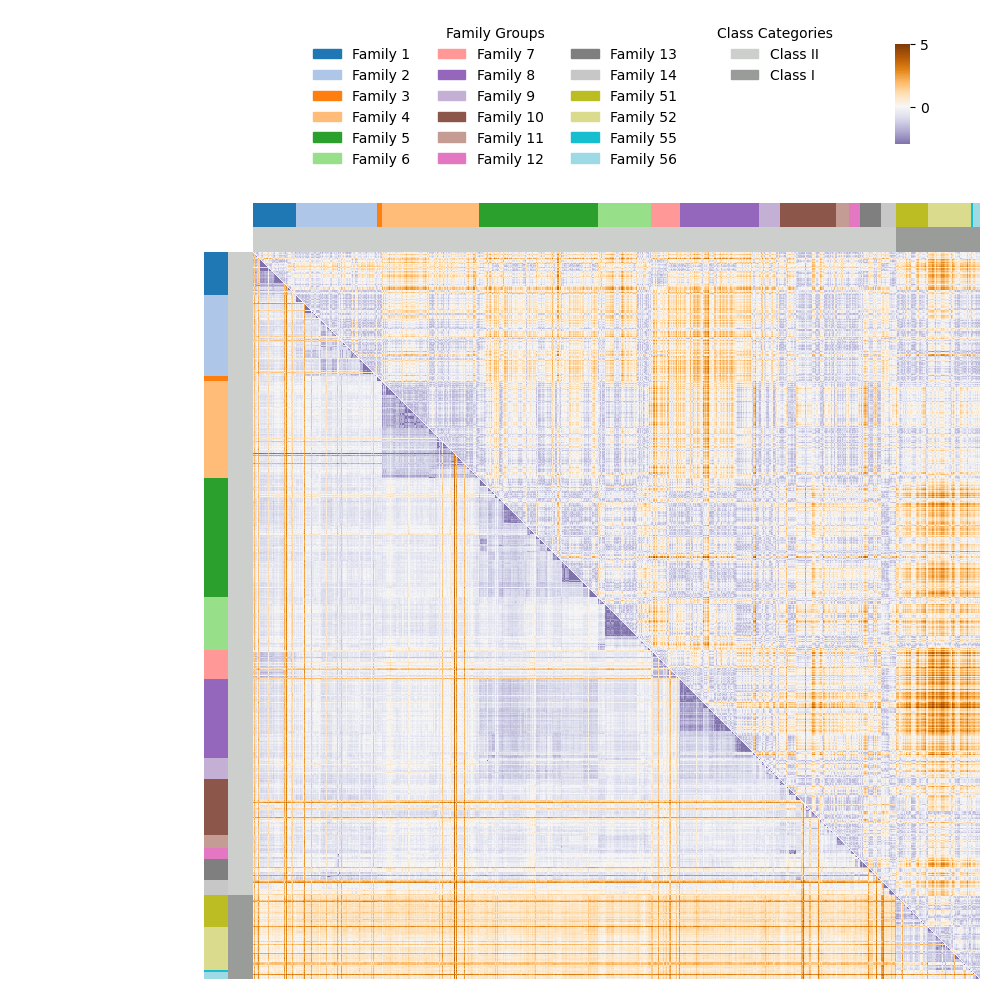

In [53]:
import seaborn as sns 
import matplotlib.patches as mpatches

# Join ESM and MDS zscore togetehr
mask_upper = np.triu(squareform(distance_df['ESM_Distance']), k=1).astype(bool)
mask_lower = np.tril(squareform(distance_df['Grantham_Distance']), k=-1).astype(bool)

plot_df = pd.DataFrame(np.zeros_like(squareform(distance_df['ESM_Distance'])), 
                       index=esm_pca_df.index, 
                       columns=esm_pca_df.index)
plot_df.values[mask_upper] = pd.DataFrame(squareform(distance_df['ESM_Distance'])).values[mask_upper]
plot_df.values[mask_lower] = pd.DataFrame(squareform(distance_df['Grantham_Distance'])).values[mask_lower]

plot_df_index = pd.Series((re.match(r'Or(\d+)', _OR).group(1) if re.match(r'Or(\d+)', _OR) else None) 
                          for _OR in plot_df.index).astype(int)



# Assign cluster colors based on family 
colors = cf.distinct_colors(plot_df_index.unique(), 
                                category='tab20')
colors = {_key: _color.upper() for _key, _color in colors.items()}

index_colors = plot_df_index.map(colors)
index_colors = [ _color.upper() for _color in index_colors]
# Assign secondary colors based on class
class_colors = sns.cubehelix_palette(2,light=.7, dark=.5, start=1, rot=3)
index_colors_class = ['#CDCFCC' if _index in range(1,15) else  '#9A9C99' for _index in plot_df_index]


# Create family/class name mappings for the legend
family_names = {family_id: f"Family {family_id}" for family_id in plot_df_index.unique()}
class_names = {
    '#CDCFCC': 'Class II',
     '#9A9C99': 'Class I'
}

# Plot the heatmap
g = sns.clustermap(plot_df, 
               cmap = 'PuOr_r',
               vmin=-3, vmax=5,
               center = 0, 
               cbar_pos = (0.9, 0.85, 0.015, 0.1), 
               row_colors = [index_colors, index_colors_class], 
               col_colors = [index_colors, index_colors_class],
               colors_ratio=(0.025, 0.025), 
               row_cluster = False, col_cluster = False,
               figsize=(10, 10), 
               xticklabels=False, yticklabels=False
               )


# Add legends for the family colors
family_handles = [mpatches.Patch(color=color, label=family_names[family_id]) 
                 for family_id, color in colors.items()]
class_handles = [mpatches.Patch(color=color, label=name) 
                 for color, name in class_names.items()]

# Position the legends
# Family legend - on top left corner
family_legend = g.fig.legend(handles=family_handles, 
                            title="Family Groups",
                            loc="upper center", 
                            bbox_to_anchor=(0.5, 0.98), 
                            frameon=False,
                            ncol=3)  # Adjust number of columns as needed

# Class legend - on top right corner
class_legend = g.fig.legend(handles=class_handles, 
                           title="Class Categories",
                           loc="upper right", 
                           frameon=False,
                           bbox_to_anchor=(0.85, 0.98))

g.savefig('../../output/pub_Figures/ESM/Heatmap_ESMvsGrantham.png', dpi=500)


### Cryo vs AF3

In [4]:
rmsd_df = pd.read_csv('../../files/cryo_vs_AF3.csv', skiprows=1)

In [5]:
# Update file to have direct information 
OR_names = []
AF_treatment = []
for i, _row in rmsd_df.iterrows(): 
    name = _row['OR']
    suffixes = [_col for _col in ['minigas', 'golf', 'ligand'] if _row[_col] == 1]
    if suffixes: 
        name+= '_' + '_'.join(suffixes)
    OR_names.append(name)
    
    suffixes.insert(0, 'OR')
    suffixes = '_'.join(suffixes)
    AF_treatment.append(suffixes)

rmsd_df['OR_name'] = OR_names
rmsd_df['AF_treatment'] = AF_treatment

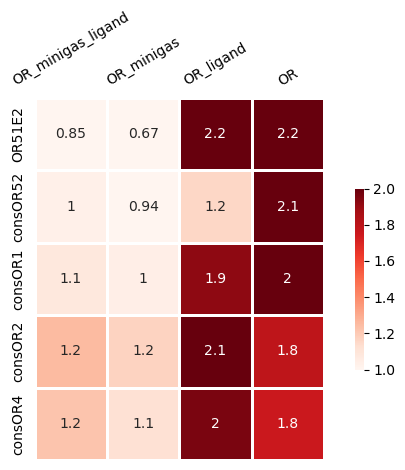

In [ ]:
"""
RMSD table for overall structure 
"""
rmsd_table = rmsd_df.pivot(index = 'OR', columns = 'AF_treatment', values = 'RMSD_all')

plot_table = rmsd_table
plot_table = plot_table.loc[['OR51E2', 'consOR52', 'consOR1', 'consOR2', 'consOR4']] # Re-order for plotting 
plot_table = plot_table[['OR', 'OR_ligand', 'OR_minigas', 'OR_minigas_ligand']]
plot_table = plot_table[['OR_minigas_ligand', 'OR_minigas', 'OR_ligand', 'OR']]


ax = sns.heatmap(plot_table, 
            vmax=2, 
            vmin=1,
            cmap = 'Reds', 
            cbar=True, 
            cbar_kws=dict(shrink=0.5), 
            linecolor = 'white', linewidths=1, 
            annot=True,
            square = True)
ax.tick_params(axis='x',labelbottom=False, bottom=False,labeltop=True, top=True, 
               rotation=30) # Move x axis labels to top 
ax.tick_params(left=False, bottom=False, top=False, right=False)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
# plt.savefig('../../output/pub_Figures/AF3/cryo_AF3_rmsd.svg', dpi=300)
plt.show()

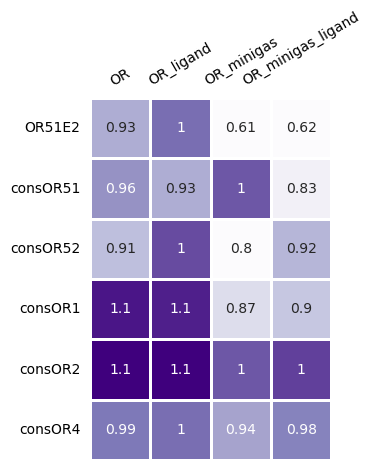

In [180]:
"""
RMSD table for pruned structure 
"""
rmsd_table = rmsd_df.pivot(index = 'OR', columns = 'AF_treatment', values = 'RMSD_pruned')

plot_table = rmsd_table
plot_table = plot_table.loc[['OR51E2', 'consOR51', 'consOR52', 'consOR1', 'consOR2', 'consOR4']] # Re-order for plotting 
plot_table = plot_table[['OR', 'OR_ligand', 'OR_minigas', 'OR_minigas_ligand']]

ax = sns.heatmap(plot_table, 
            vmax=1.1, vmin=0.8,
            cmap = 'Purples', 
            cbar=False, 
            linecolor = 'white', linewidths=1, 
            annot=True,
            square = True)
ax.tick_params(axis='x',labelbottom=False, bottom=False,labeltop=True, top=True, 
               rotation=30) # Move x axis labels to top 
ax.tick_params(left=False, bottom=False, top=False, right=False)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../../output/pub_Figures/AF3/cryo_AF3_rmsd_pruned.svg', dpi=300)
plt.show()

### Model Output Plots

#### Model performance. 

##### Model Classification correlation with pS6

In [36]:
# Load your single model outputs
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

test_labels = np.load(os.path.join(base_dir, 'test_labels.npy'))
test_preds  = np.load(os.path.join(base_dir, 'test_preds.npy'))
test_probs  = np.load(os.path.join(base_dir, 'test_probs.npy'))
test_names = np.load(os.path.join(base_dir, 'test_voxel_names.npy'), allow_pickle=True)


In [30]:
"""
For each odor, what is the correlation of response (prob/label from model) vs pS6-IP activation zscore
"""

# Make Prediction data table 
mask = pd.Series([_or.split('_')[0] for _or in test_names]).isin(ps6_df.DL_OR.unique())
pred_data = pd.DataFrame(test_preds[mask], 
                         index = pd.Series([_or.split('_')[0] for _or in test_names])[mask], 
                         columns = ODORS)
pred_data = pred_data.sort_index()
# pred_data = pred_data.groupby(pred_data.index).mean()

prob_data = pd.DataFrame(test_probs[mask], 
                         index = pd.Series([_or.split('_')[0] for _or in test_names])[mask], 
                         columns = ODORS)
prob_data = prob_data.sort_index()
# prob_data = prob_data.groupby(prob_data.index).mean()

# Binarize pS6-IP and make table 
ps6_table = ps6_df[['DL_OR', 'odor', 'activation_zscore']].sort_values('activation_zscore', ascending=False).drop_duplicates(['DL_OR', 'odor']).reset_index(drop=True)
ps6_table = ps6_table[ps6_table.DL_OR.isin(pred_data.index)]
ps6_table['label'] = ps6_table.activation_zscore.apply(lambda x: 1.0 if x >= 2 else 0)
ps6_table = ps6_table.pivot(index='DL_OR', columns = 'odor', values='label')
ps6_table = ps6_table[ODORS]

/tmp/ipykernel_1301603/2000742983.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



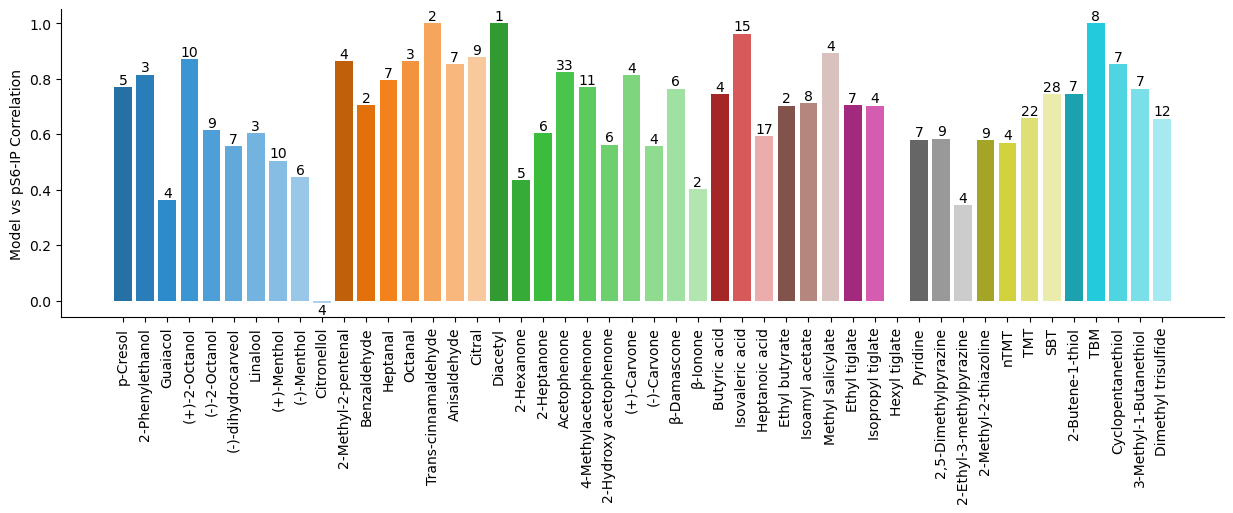

In [76]:
"""
Correlation plot between pS6-IP labels and CNN prediction
"""
from scipy.stats import pearsonr

plt.figure(figsize=(15,4))
plot_data = pred_data.corrwith(ps6_table, method='pearson')

plot_data = plot_data.loc[ODORS] # Re-order based on defined order

bars = plt.bar(x = ODORS, 
        height = plot_data, 
        color = [ODOR_COLORS.get(_o) for _o in ODORS])

ax = plt.gca()
ax.bar_label(bars, labels=test_labels.sum(axis=0).astype(int))
ax.set_xticklabels(labels = ODORS, rotation=90)
ax.set_ylabel('Model vs pS6-IP Correlation')
ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../output/pub_Figures/model/corr_pred_pS6.svg', dpi=500)
plt.show()

# correlation_coefficient, p_value = pearsonr(prob_data, ps6_table)

/tmp/ipykernel_1301603/2387422990.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



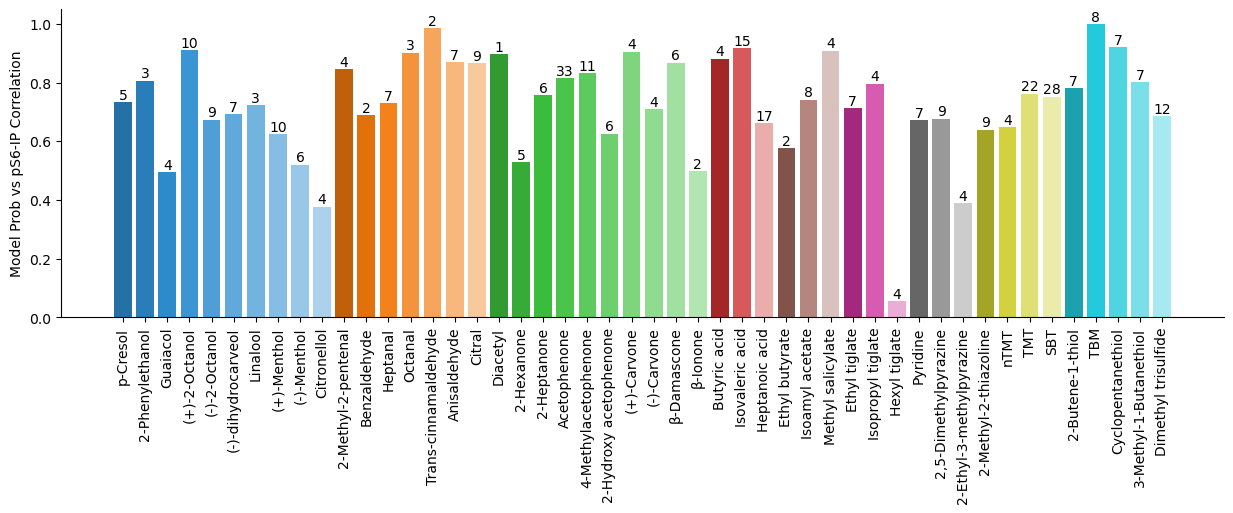

In [75]:
"""
Correlation plot between pS6-IP labels and CNN probability
"""
from scipy.stats import pearsonr

plt.figure(figsize=(15,4))
plot_data = prob_data.corrwith(ps6_table, method='pearson')

plot_data = plot_data.loc[ODORS] # Re-order based on defined order

bars = plt.bar(x = ODORS, 
               height = plot_data, 
               color = [ODOR_COLORS.get(_o) for _o in ODORS])

ax = plt.gca()
ax.bar_label(bars, labels=test_labels.sum(axis=0).astype(int))
ax.set_xticklabels(labels = ODORS, rotation=90)
ax.set_ylabel('Model Prob vs pS6-IP Correlation')
ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../output/pub_Figures/model/corr_prob_pS6.svg', dpi=500)
plt.show()

# correlation_coefficient, p_value = pearsonr(prob_data, ps6_table)

##### training plots 

In [4]:
# Load your single model outputs
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

train_loss = np.load(os.path.join(base_dir, 'train_losses.npy'))
val_loss = np.load(os.path.join(base_dir, 'val_losses.npy'))

val_accs = np.load(os.path.join(base_dir, 'val_accs.npy'))

test_labels = np.load(os.path.join(base_dir, 'test_labels.npy'))
test_preds  = np.load(os.path.join(base_dir, 'test_preds.npy'))
test_probs  = np.load(os.path.join(base_dir, 'test_probs.npy'))
test_names = np.load(os.path.join(base_dir, 'test_voxel_names.npy'), allow_pickle=True)



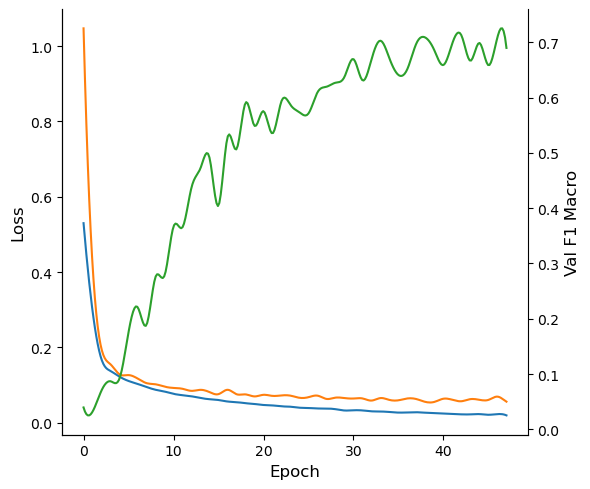

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

x = np.arange(len(train_loss))  # Epochs

# Smooth curves using spline interpolation (optional)
x_smooth = np.linspace(x.min(), x.max(), 300)
spl_train = make_interp_spline(x, train_loss, k=3)
train_loss_smooth = spl_train(x_smooth)

spl_val = make_interp_spline(x+1, val_loss, k=3)
val_loss_smooth = spl_val(x_smooth)

spl_acc = make_interp_spline(x, val_accs, k=3)
val_accs_smooth = spl_acc(x_smooth)

fig, ax1 = plt.subplots(figsize=(6,5))

# Plot train and val loss on left y-axis
ax1.plot(x_smooth, train_loss_smooth, label="Train Loss", color='tab:blue')
ax1.plot(x_smooth, val_loss_smooth, label="Val Loss", color='tab:orange')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.spines[['right', 'top']].set_visible(False)

# Create second y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(x_smooth, val_accs_smooth, label="Val F1 macro", color='tab:green')
ax2.set_ylabel('Val F1 Macro', fontsize=12)
ax2.spines['right'].set_visible(True)  # Keep right spine visible for second y-axis
ax2.spines['top'].set_visible(False)

# plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

plt.savefig('../../output/pub_Figures/model/train_curve.svg', dpi=500)

plt.show()


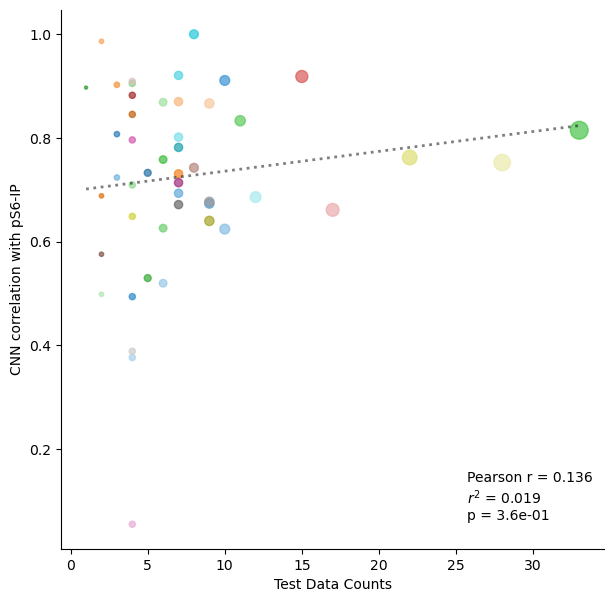

In [37]:
from scipy.stats import pearsonr, linregress
from matplotlib.ticker import LogLocator


# Loading specific path for saved train data. . . 
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'
train_labels = np.load(os.path.join(base_dir, 'train_labels.npy'))
train_names  = np.load(os.path.join(base_dir, 'train_voxel_names.npy'))

values1, values2 = test_labels.sum(axis=0), prob_data.corrwith(ps6_table, method='pearson').values
plt.figure(figsize=(7,7))
plt.scatter(x = values1, 
            y = values2, 
            color = [ODOR_COLORS.get(_o) for _o in ODORS], 
            s = test_labels.sum(axis=0)*5, 
            alpha=0.7
        )


r, p_value = pearsonr(values1, values2)
slope, intercept, *_ = linregress(values1, values2)
sorted_idx = np.argsort(values1)
plt.plot(values1[sorted_idx], slope * values1[sorted_idx] + intercept, 
         color='black',
         linestyle='dotted',
         linewidth=2,
         alpha=0.5
)
plt.text(0.7, 0.1,
        f"Pearson r = {r:.3f}\n$r^2$ = {r**2:.3f}\np = {p_value:.1e}",
        fontsize=10,
        ha='left', va='top',
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3",
                edgecolor="white",
                facecolor="white", alpha=0))

ax = plt.gca()
# ax.set_xticklabels(labels = ['10','10^2','10^3'])
# ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=None))
ax.set_ylabel('CNN correlation with pS6-IP')
ax.set_xlabel('Test Data Counts')
ax.spines[['right', 'top']].set_visible(False)

# plt.savefig('../../output/pub_Figures/model/corr_prob_ntest.svg', dpi=500)
plt.show()

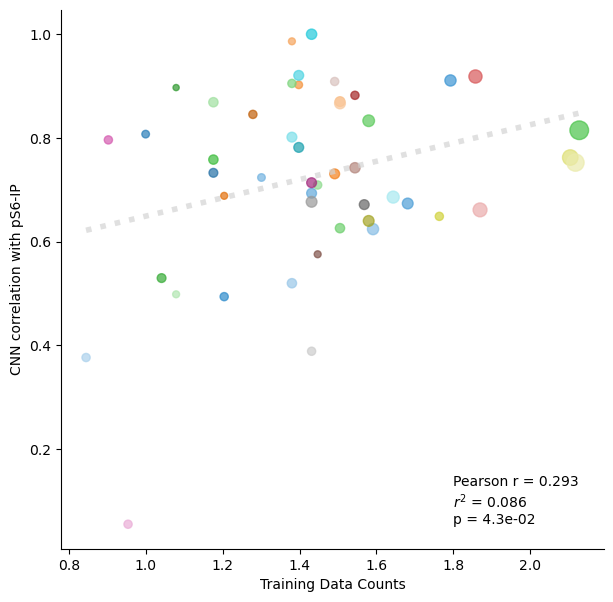

In [47]:
from scipy.stats import pearsonr, linregress
from matplotlib.ticker import LogLocator


# Loading specific path for saved train data. . . 
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'
train_labels = np.load(os.path.join(base_dir, 'train_labels.npy'))
train_names  = np.load(os.path.join(base_dir, 'train_voxel_names.npy'))

values1, values2 = np.log10(train_labels.sum(axis=0)), prob_data.corrwith(ps6_table, method='pearson').values
plt.figure(figsize=(7,7))
plt.scatter(x = values1, 
            y = values2, 
            color = [ODOR_COLORS.get(_o) for _o in ODORS], 
            s = (test_labels.sum(axis=0) + 3) * 5, 
            alpha=0.7
        )


r, p_value = pearsonr(values1, values2)
slope, intercept, *_ = linregress(values1, values2)
sorted_idx = np.argsort(values1)
plt.plot(values1[sorted_idx], slope * values1[sorted_idx] + intercept, 
         color='#D3D3D3',
         linestyle='dotted',
         linewidth=4,
         alpha=0.7
)
plt.text(1.8, 0.15,
        f"Pearson r = {r:.3f}\n$r^2$ = {r**2:.3f}\np = {p_value:.1e}",
        fontsize=10,
        ha='left', va='top',
        # transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3",
                edgecolor="white",
                facecolor="white", alpha=0))

ax = plt.gca()
# ax.set_xticklabels(labels = ['10','10^2','10^3'])
# ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=None))
ax.set_ylabel('CNN correlation with pS6-IP')
ax.set_xlabel('Training Data Counts')
ax.spines[['right', 'top']].set_visible(False)

# plt.savefig('../../output/pub_Figures/model/corr_prob_ntrain.svg', dpi=500)
plt.show()

##### Individual Curves 

In [5]:
"""
ROC
"""

import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc
import numpy as np


# Prepare common FPR grid
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

fig = go.Figure()
for i, _odor in enumerate(ODORS):
    # Skip classes with no positive examples
    if np.sum(test_labels[:, i]) == 0:
        continue
        
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
    roc_auc_i = auc(fpr, tpr)

    # odor_cat = ODOR_TO_CAT[_odor]
    # color = CATEGORY_COLORS[odor_cat]
    
    color = ODOR_COLORS.get(_odor)

    # Add individual ROC curve (faded)
    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            name = _odor,  
            text=f"{_odor}, AUC: {roc_auc_i:3f}", 
            mode='lines',
            line=dict(color=color, width=3),
            opacity=0.5,
            # showlegend=False
        )
    )

    # Collect for category averaging
    tpr_interp = np.interp(overall_mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_i)

# --- Mean ROC ---
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0
overall_mean_auc = np.mean(aucs)

fig.add_trace(
    go.Scatter(
        x=overall_mean_fpr,
        y=overall_mean_tpr,
        mode='lines',
        line=dict(color='black', width=3),
        text=f"Mean ROC (AUC = {overall_mean_auc:.2f})", 
    )
)

# --- Reference diagonal line ---
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode='lines',
        line=dict(color='black', width=1, dash='dash'),
        showlegend=False
    )
)

# --- Layout ---
fig.update_layout(
    title='ROC Curves by Odor (Plotly)',
    xaxis=dict(title='False Positive Rate', range=[0, 1.05]),
    yaxis=dict(title='True Positive Rate', range=[0, 1.05]),
    template='simple_white',
    height = 500, width = 500, 
    showlegend=False
)

fig.show()
# fig.write_html('../../output/pub_Figures/model/aucroc.html')
# fig.write_image('../../output/pub_Figures/model/aucroc.svg', height=500, width=500, scale=5)
# fig.write_image('../../output/pub_Figures/model/aucroc.png', height=500, width=500, scale=5)

/tmp/ipykernel_1301603/1263481501.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



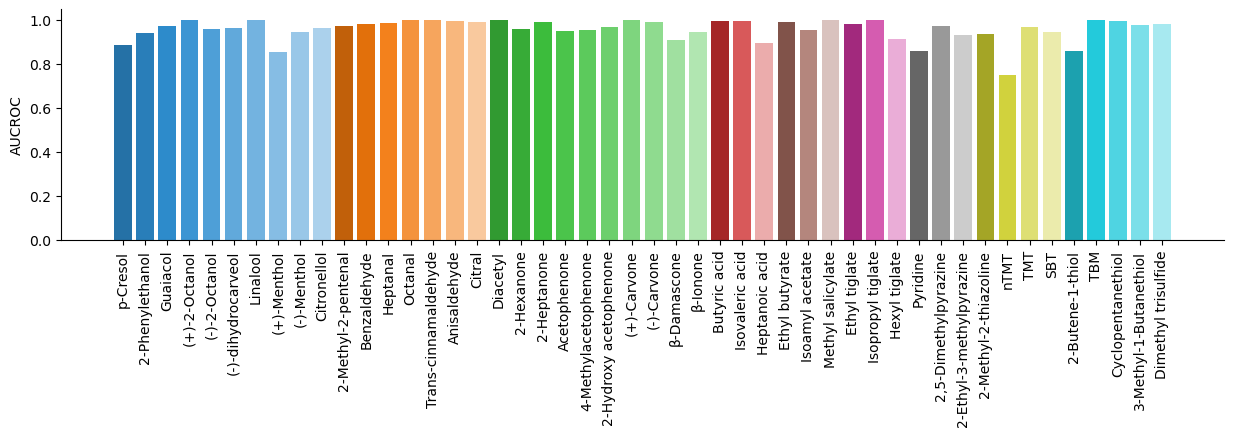

In [24]:
"""
Individual ROC 
"""


plt.figure(figsize=(15,3))
plot_data = pd.DataFrame(aucs, 
             columns = ['ROCAUC'], 
             index=ODORS)

plot_data = plot_data.loc[ODORS] # Re-order based on defined order


plt.bar(x = plot_data.index, 
        height = plot_data.ROCAUC, 
        color = [ODOR_COLORS.get(_o) for _o in plot_data.index])

ax = plt.gca()
ax.set_xticklabels(labels = plot_data.index, rotation=90)
ax.set_ylabel('AUCROC')
ax.spines[['right', 'top']].set_visible(False)
plt.show()



In [ ]:
# import plotly.graph_objects as go
# from sklearn.metrics import roc_curve, auc
# import numpy as np


# # Model labels were previously trained on default sorted method...
# model_odor_order = sorted(ps6_df.odor.unique())

# plot_odor = []
# for i, _odor in enumerate(model_odor_order):
#     # Skip classes with no positive examples
#     if np.sum(val_labels[:, i]) == 0:
#         continue
#     plot_odor.append(_odor)
    
# fig = go.Figure()    
# for i, _odor in enumerate(plot_odor): 
    
#     odor_cat = ODOR_TO_CAT[_odor]
#     color = CATEGORY_COLORS[odor_cat]
    
#     subset = ps6_df[(ps6_df.odor == _odor) & 
#                            (ps6_df.activation_zscore >= 2)]
#     plot_property = len(subset)
#     # plot_property = subset.activation_zscore.mean()
    

#     # Add individual ROC curve (faded)
#     fig.add_trace(
#         go.Scatter(
#             x=[plot_property],
#             y=[aucs[i]],
#             name = _odor,  
#             text=f"{_odor}, n ORs: {plot_property}", 
#             mode='markers',
#             marker=dict(color=color, size=10),
#             opacity=0.5,
#             showlegend=False
#         )
#     )


# # --- Layout ---
# fig.update_layout(
#     # xaxis=dict(title='number Reponding ORs'),
#     xaxis=dict(title='Activation z-score'),
#     yaxis=dict(title='AUCROC'),
#     template='simple_white',
#     height = 500, width = 500
# )

# fig.show()
# fig.write_html('../../output/pub_Figures/model/corr_aucroc_activationzscore.html')
# fig.write_image('../../output/pub_Figures/model/corr_aucroc_activationzscore.svg', width=500, height=500)

# # fig.write_html('../../output/pub_Figures/model/corr_aucroc_nOR.html')
# # fig.write_image('../../output/pub_Figures/model/corr_aucroc_nOR.svg', width=500, height=500)

In [ ]:
# Save and export the rocauc values
mw_info = ps6_df[['odor', 'cid_mw', 'odor_category']].drop_duplicates()
odor_cat_order = ['Alcohols', 'Aldehydes', 'Ketones','CarboxylicAcids', 
                  'Esters', 'Tiglates', 'Pyradine', 'Thiazole', 'Sulfurous']
mw_info.odor_category = pd.Categorical(mw_info.odor_category, categories=odor_cat_order, ordered=True)
mw_info = mw_info.sort_values('odor_category').reset_index(drop=True)

auc_dict = {_odor: auc for _odor, auc in zip(ODORS, aucs)}
mw_info['auc'] = [auc_dict.get(_odor) for _odor in mw_info.odor]

# mw_info.to_csv('../../output/pub_Figures/model/rocauc_values.csv')

In [25]:
"""
Precision-Recall Curve 
"""
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np


# Prepare Recall grid (common x-axis)
overall_mean_recall = np.linspace(0, 1, 100)
precisions = []
aps = []

fig = go.Figure()

for i, _odor in enumerate(ODORS):
    # Skip classes with no positive examples
    if np.sum(test_labels[:, i]) == 0:
        continue
    
    precision, recall, _ = precision_recall_curve(test_labels[:, i], test_probs[:, i])
    ap_i = average_precision_score(test_labels[:, i], test_probs[:, i])

    odor_cat = ODOR_TO_CAT[_odor]
    color = CATEGORY_COLORS[odor_cat]

    # Add individual PR curve
    fig.add_trace(
        go.Scatter(
            x=recall,
            y=precision,
            name=_odor,
            text=f"{_odor}, AP: {ap_i:.3f}",
            mode='lines',
            line=dict(color=color, width=4),
            opacity=0.35
        )
    )

    # Interpolate precision at fixed recall points
    precision_interp = np.interp(overall_mean_recall, np.flip(recall), np.flip(precision))
    precisions.append(precision_interp)
    aps.append(ap_i)

# Mean PR Curve
overall_mean_precision = np.mean(precisions, axis=0)
overall_mean_ap = np.mean(aps)

fig.add_trace(
    go.Scatter(
        x=overall_mean_recall,
        y=overall_mean_precision,
        mode='lines',
        line=dict(color='black', width=3),
        name=f"Mean PR (AP = {overall_mean_ap:.2f})"
    )
)

# Layout
fig.update_layout(
    title='Precision-Recall Curves by Odor (Plotly)',
    xaxis=dict(title='Recall', range=[0, 1]),
    yaxis=dict(title='Precision', range=[0, 1.05]),
    template='simple_white',
    height=500,
    width=500, 
    showlegend=False
)

fig.show()
# fig.write_html('../../output/pub_Figures/model/aucroc.html')
# fig.write_image('../../output/pub_Figures/model/aucroc.svg')

In [6]:
# Load your single model outputs
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/final_model/20251118_173316_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue'

f1_table = pd.read_csv(os.path.join(base_dir, 'test_classification_report.csv'))


/tmp/ipykernel_1301603/3519841679.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



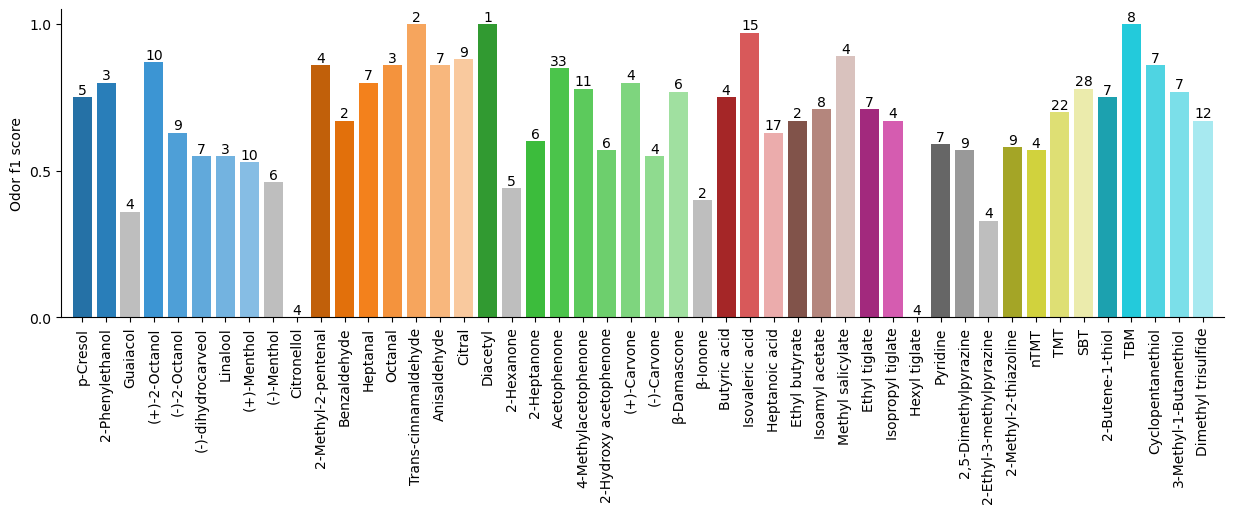

In [74]:
"""
CNN precision and recall f1 score 
"""

plt.figure(figsize=(15,4))

plot_data = f1_table.loc[ODORS] # Re-order based on defined order
bars = plt.bar(x = ODORS, 
               height = plot_data['f1-score'], 
            #    color = [ODOR_COLORS.get(_o) for _o in ODORS])
               color = [ODOR_COLORS.get(_o) if f1_table.loc[_o]['f1-score'] > 0.5 else '#BEBEBE' for _o in ODORS])


ax = plt.gca()
ax.margins(x=0.01)
ax.bar_label(bars, labels=test_labels.sum(axis=0).astype(int))
ax.set_xticklabels(labels = ODORS, rotation=90)
ax.set_yticks([0, 0.5, 1])
ax.set_ylabel('Odor f1 score')
ax.spines[['right', 'top']].set_visible(False)

# plt.axhline(y = 0.5, xmin=0, xmax = 1, 
#             linestyle='--', dashes=(5,10), color = '#D3DED3')

plt.savefig('../../output/pub_Figures/model/f1_score.svg', dpi=500)
plt.show()


/tmp/ipykernel_3671261/1124731728.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



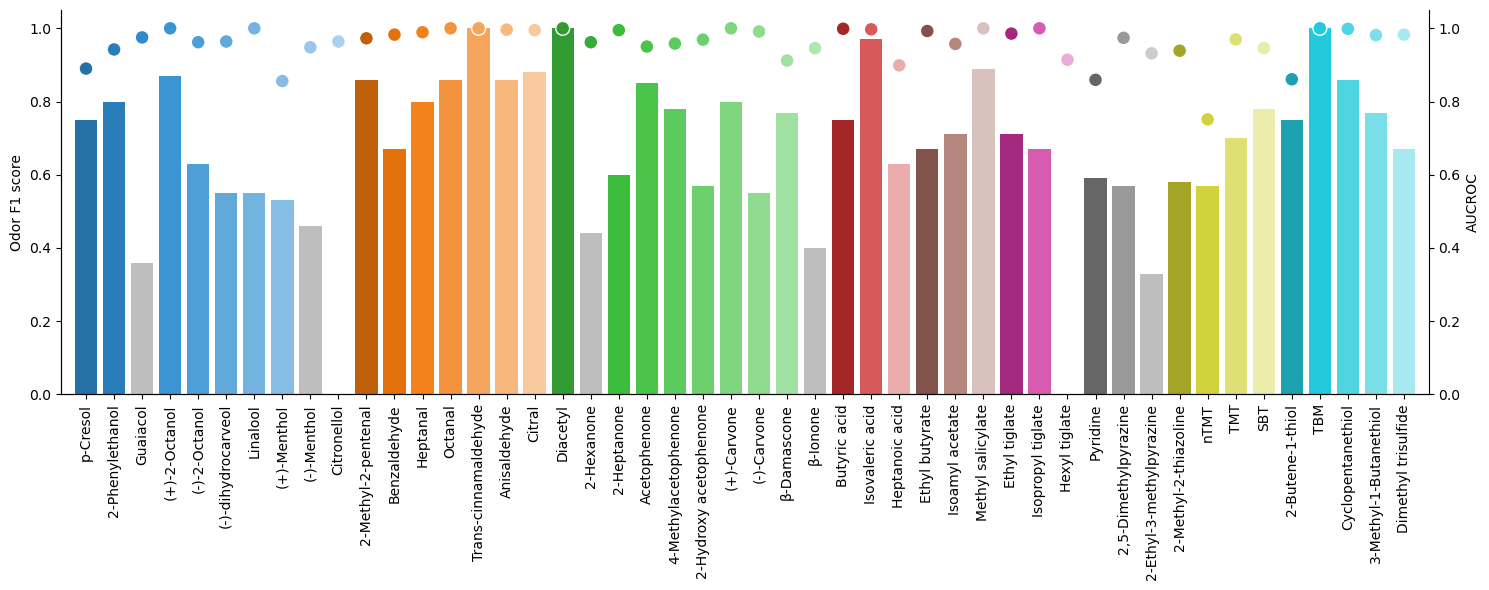

In [25]:
"""
Combining F1 score and AUCROC in single plot 
"""

fig, ax1 = plt.subplots(figsize=(15,6))

# --- F1 bars on left axis ---
plot_data_f1 = f1_table.loc[ODORS]

bars = ax1.bar(
    x=ODORS,
    height=plot_data_f1['f1-score'],
    color=[ODOR_COLORS.get(_o) if f1_table.loc[_o]['f1-score'] > 0.5 else '#BEBEBE'
           for _o in ODORS]
)

ax1.margins(x=0.01)
# ax1.bar_label(bars, labels=test_labels.sum(axis=0).astype(int))
ax1.set_xticklabels(labels=ODORS, rotation=90)
# ax1.set_yticks([0, 0.5, 1])
ax1.set_ylabel('Odor F1 score')
ax1.spines[['right', 'top']].set_visible(False)

# --- AUCROC line/points on right axis ---
ax2 = ax1.twinx()

plot_data_auc = pd.DataFrame(aucs, columns=['ROCAUC'], index=ODORS).loc[ODORS]

ax2.scatter(
    ODORS,
    plot_data_auc['ROCAUC'],
    color=[ODOR_COLORS.get(_o) for _o in ODORS],
    s=100, 
    marker='o',
    edgecolors='white',
    linewidth=1,
    label='AUCROC'
)
ax2.margins(x=0.01)
ax2.set_ylabel('AUCROC')
# ax2.set_yticks([0, 0.5, 1])
# ax2.set_ylim(0.5, 1.05)  # assuming AUC in [0,1]
ax2.spines['top'].set_visible(False)


# ax1.set_ylim(0.5, 1.05)  # assuming AUC in [0,1]
ax2.set_ylim(0, 1.05)  # assuming AUC in [0,1]


# Optional legend (using ax2 handle for AUC, ax1 for F1)
f1_proxy = plt.Line2D([0], [0], color='grey', linewidth=0, marker='s', label='F1 (bars)')
auc_proxy = plt.Line2D([0], [0], color='black', marker='o', label='AUCROC (line)')
# ax1.legend(handles=[f1_proxy, auc_proxy], loc='upper right')

plt.tight_layout()

plt.savefig('../../output/pub_Figures/model/AUCROC_f1_score.svg', dpi=500)
plt.show()

In [19]:
plot_data_f1

,precision,recall,f1-score,support,aucroc
p-Cresol,1.00,0.60,0.75,5,0.890000
2-Phenylethanol,1.00,0.67,0.80,3,0.942244
Guaiacol,0.29,0.50,0.36,4,0.975124
(+)-2-Octanol,0.77,1.00,0.87,10,1.000000
(-)-2-Octanol,0.60,0.67,0.63,9,0.962018
(-)-dihydrocarveol,0.75,0.43,0.55,7,0.963925
Linalool,0.38,1.00,0.55,3,1.000000
(+)-Menthol,0.56,0.50,0.53,10,0.855897
(-)-Menthol,0.43,0.50,0.46,6,0.948074
Citronellol,0.00,0.00,0.00,4,0.963930


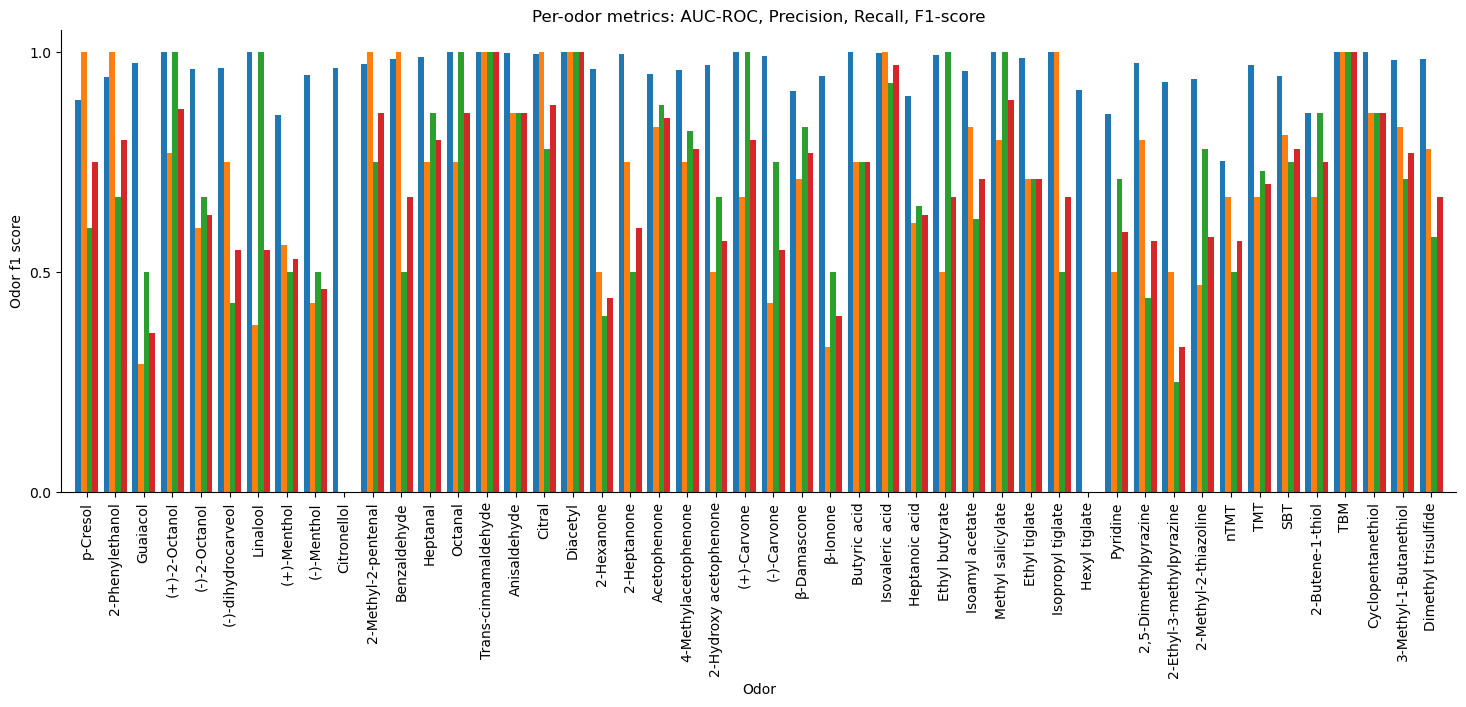

In [26]:
"""
Combining F1 score and AUCROC in single plot, multi-bar
"""

# plt.figure(figsize=(15,4))

# --- F1 bars on left axis ---
plot_data_f1 = f1_table.loc[ODORS]
plot_data_f1['aucroc'] = aucs

# bars = plt.bar(x = ODORS, 
#                height = plot_data['f1-score'], 
#             #    color = [ODOR_COLORS.get(_o) for _o in ODORS])
#                color = [ODOR_COLORS.get(_o) if f1_table.loc[_o]['f1-score'] > 0.5 else '#BEBEBE' for _o in ODORS])

# Metrics to plot
metrics = ["aucroc", "precision", "recall", "f1-score"]

# X positions for odors
x = np.arange(len(ODORS))  # one position per odor

width = 0.2  # width of each bar

fig, ax = plt.subplots(figsize=(18, 6))

# Plot one bar series per metric
ax.bar(x - 1.5*width, plot_data_f1["aucroc"],    width, label="AUC-ROC")
ax.bar(x - 0.5*width, plot_data_f1["precision"], width, label="Precision")
ax.bar(x + 0.5*width, plot_data_f1["recall"],    width, label="Recall")
ax.bar(x + 1.5*width, plot_data_f1["f1-score"],  width, label="F1-score")

# X-axis labels: odor names from the index
ax.set_xticks(x)
ax.set_xticklabels(plot_data_f1.index, rotation=90)

ax.set_ylabel("Score")
ax.set_xlabel("Odor")
ax.set_title("Per-odor metrics: AUC-ROC, Precision, Recall, F1-score")
ax.set_ylim(0, 1.05)
# ax.legend()
    
ax = plt.gca()
ax.margins(x=0.01)
# ax.bar_label(bars, labels=test_labels.sum(axis=0).astype(int))
ax.set_xticklabels(labels = ODORS, rotation=90)
ax.set_yticks([0, 0.5, 1])
ax.set_ylabel('Odor f1 score')
ax.spines[['right', 'top']].set_visible(False)

plt.show()